# Subscription-Trajectory Classification - 03 - Deep Learning (sequence + tabular)

**Idea.** Notebooks 01 (direct multiclass) and 02 (two-stage) both rely on
*engineered* tabular summaries of pre-expiry behaviour (29 base features + the
horizon windows). This notebook takes the **raw 60-day listening sequence** and
lets a recurrent network learn the temporal shape of engagement itself, then
fuses it with the static tabular signal.

**Model - a hybrid network.**

* **Sequence branch.** The daily panel `events_daily_panel.parquet` gives, for
  every expiry event, up to 60 daily vectors `(total_secs, num_100, num_unq,
  num_25)` at offsets `-60..-1`. We pivot + zero-pad each event to a dense
  `(60, 4)` tensor and run a **GRU** over it, taking the final hidden state as a
  learned engagement embedding.
* **Static branch.** The same 29 base features as notebook 01 - numeric features
  standardised, the 5 categoricals passed through **embedding layers** - through
  a small MLP.
* **Fusion head.** Concatenate the two and predict the 4 classes
  (`CHURN / CONTRACTION / STABLE / EXPANSION`).

We also train a **static-only** version (sequence branch removed) as an
ablation, so any gain is attributable to the raw sequence.

**Headline question.** Does end-to-end deep learning on the raw sequence beat the
gradient-boosted tabular champion (the **direct** model from notebook 01) and the
two-stage pipeline (02)? Their held-out numbers are loaded live from disk for the
comparison, so this notebook always benchmarks against the current re-run.

**Protocol.** Identical contract to 01/02 - user-grouped split for train/val,
the same held-out users for the final number, no leakage columns. The 60-day
tensor is built once and cached to `KKBoxData/seq_cache/`; trained weights and
metrics are persisted so re-runs are cheap. The **time-before-renewal** analysis
(§10) additionally builds a deeper **120-day** cache directly from the raw
`user_logs`, so a fixed 60-day window can slide back to end at earlier decision
points `E-c` (matching how 01/02 define their cutoff features) - this is separate
from and does not alter the 60-day main-model cache. Training uses the GPU
(CUDA / Apple-Silicon MPS) when available, otherwise the CPU.

In [ ]:
import os, warnings; warnings.filterwarnings('ignore')
import time, json, math, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
import clf_utils as U

# ===== MACHINE CONFIG (device selection) =====
RNG = U.RANDOM_STATE
torch.manual_seed(RNG); np.random.seed(RNG)
device = torch.device('mps' if torch.backends.mps.is_available()
                      else ('cuda' if torch.cuda.is_available() else 'cpu'))
NUM_WORKERS = 0                # MPS + multiprocessing DataLoader is unstable -> single-process loading
PIN_MEMORY  = False           # pin_memory only benefits CUDA
SEQ_IN_RAM  = True            # 60d tensor ~1.7 GB float16 -> fits in RAM, faster than memmap disk reads
FORCE_TRAIN = False           # resume: reuse cached seed checkpoints instead of retraining
print('torch', torch.__version__, '| device:', device, '| workers:', NUM_WORKERS)
print('model classes:', U.MODEL_CLASSES)

torch 2.8.0 | device: mps | workers: 0
model classes: ['CHURN', 'CONTRACTION', 'STABLE', 'EXPANSION']


## 1 - Load tabular events, targets & splits

Same modellable event table and leakage-guarded base matrix as notebook 01. We
keep `msno` and `E` to align each row with its 60-day sequence.


In [2]:
df = U.load_events('base', modellable_only=True)
X  = U.build_X(df, 'base')
y  = U.y_multiclass(df)
mask_dev, mask_ho = U.dev_mask(df), U.holdout_mask(df)
print('rows:', f'{len(df):,}', '| dev:', f'{mask_dev.sum():,}', '| holdout:', f'{mask_ho.sum():,}')
print('class balance (dev):')
print(pd.Series(y[mask_dev]).map(U.CODE_TO_CLASS).value_counts(normalize=True).round(4))


rows: 3,784,500 | dev: 3,215,995 | holdout: 568,505
class balance (dev):
STABLE         0.6309
EXPANSION      0.1729
CONTRACTION    0.1538
CHURN          0.0424
Name: proportion, dtype: float64


## 2 - Build (or load) the 60-day sequence tensor

The daily panel is long format and large (~143M rows). We stream it in row-group
chunks, align each `(msno, E)` to its event row, and scatter the four channels
into a dense `float16` memmap of shape `(n_events, 60, 4)` (offset `-60..-1` ->
time index `0..59`, missing days left at 0). The result is cached so this only
runs once; we also report what fraction of events have any sequence coverage.

This 60-day tensor is the input to the **main model** (§5-§9) and the confusion
matrix (§11). The time-before-renewal analysis (§10) later builds a **separate**
deeper 120-day cache (`seq_modellable_120d.npy`, straight from raw `user_logs`)
for its sliding window - it does **not** replace this one; its recent-60 slice
reproduces exactly this tensor.


In [3]:
SEQ_WINDOW = 60
SEQ_FEATURES = ['total_secs', 'num_100', 'num_unq', 'num_25']
SEQ_DIR = U.DATA / 'seq_cache'; SEQ_DIR.mkdir(exist_ok=True)
SEQ_ARR = SEQ_DIR / 'seq_modellable_60d.npy'
SEQ_KEY = SEQ_DIR / 'seq_modellable_keys.npy'
PANEL   = U.DATA / 'events_daily_panel.parquet'

def _keys(frame):
    e = pd.to_datetime(frame['E']).dt.normalize().astype('int64').astype(str)
    return (frame['msno'].astype(str) + '|' + e).to_numpy()

def build_sequence_cache(df, force=False):
    import pyarrow.parquet as pq
    keys = _keys(df); n = len(keys)
    if SEQ_ARR.exists() and SEQ_KEY.exists() and not force:
        cached = np.load(SEQ_KEY, allow_pickle=True)
        if len(cached) == n and np.array_equal(cached, keys):
            arr = np.load(SEQ_ARR, mmap_mode='r')
            print('loaded cached sequence tensor', arr.shape)
            return arr, keys
        print('cache key mismatch -> rebuilding')
    ki = pd.Series(np.arange(n), index=pd.Index(keys))
    dup = int(ki.index.duplicated().sum())
    if dup: print('warning: dropping', dup, 'duplicate event keys (keep first)')
    ki = ki[~ki.index.duplicated(keep='first')]
    arr = np.lib.format.open_memmap(SEQ_ARR, mode='w+', dtype='float16',
                                    shape=(n, SEQ_WINDOW, len(SEQ_FEATURES)))
    arr[:] = 0
    pf = pq.ParquetFile(PANEL); matched = 0; t0 = time.time()
    for rg in range(pf.num_row_groups):
        ch = pf.read_row_group(rg, columns=['msno', 'E', 'offset'] + SEQ_FEATURES).to_pandas()
        ridx = ki.reindex(_keys(ch)).to_numpy()
        m = ~np.isnan(ridx)
        if not m.any(): continue
        ri = ridx[m].astype(np.int64)
        ti = (ch['offset'].to_numpy()[m] + SEQ_WINDOW).astype(np.int64)
        good = (ti >= 0) & (ti < SEQ_WINDOW)
        ri, ti = ri[good], ti[good]
        arr[ri, ti, :] = ch[SEQ_FEATURES].to_numpy()[m][good].astype('float16')
        matched += int(good.sum())
        if rg % 25 == 0:
            print(f'  row group {rg:3d}/{pf.num_row_groups}  matched={matched:,}  {time.time()-t0:.0f}s')
    arr.flush(); np.save(SEQ_KEY, keys)
    nz = np.zeros(n, dtype=bool)
    for s in range(0, n, 500_000):
        e = min(s + 500_000, n)
        nz[s:e] = (np.asarray(arr[s:e]).reshape(e - s, -1) != 0).any(1)
    print(f'built sequence tensor {arr.shape}  scatter rows={matched:,}  event coverage={nz.mean():.3f}')
    return np.load(SEQ_ARR, mmap_mode='r'), keys

seq_arr, seq_keys = build_sequence_cache(df)
if SEQ_IN_RAM:
    seq_arr = np.array(seq_arr, dtype='float16')  # pin the whole tensor in RAM (fast random access)
    print('sequence tensor resident in RAM:', seq_arr.shape, seq_arr.dtype)
has_seq = np.zeros(len(df), bool)
for s in range(0, len(df), 500_000):
    e = min(s + 500_000, len(df))
    has_seq[s:e] = (np.asarray(seq_arr[s:e]).reshape(e - s, -1) != 0).any(1)
print('events with >=1 active day in last 60d:', f'{has_seq.sum():,}', f'({has_seq.mean():.3f})')


loaded cached sequence tensor (3784500, 60, 4)
sequence tensor resident in RAM: (3784500, 60, 4) float16
events with >=1 active day in last 60d: 3,784,500 (1.000)


## 3 - Encode static features & sequence normalisation stats

Numeric base features are median-imputed and standardised (statistics fit on dev
only); the 5 categoricals are integer-encoded for embedding layers (an extra
index reserved for missing/unseen). Sequence channels are `log1p`-compressed
(heavy right tails) and standardised per channel using a dev sample.


In [4]:
NUM_COLS = U.numeric_columns(X)
CAT_COLS = U.categorical_columns(X)

# numeric: dev median impute + standardise
Xnum_raw = X[NUM_COLS].to_numpy('float32')
dev_med = np.nanmedian(Xnum_raw[mask_dev], axis=0)
inds = np.where(np.isnan(Xnum_raw))
Xnum_raw[inds] = np.take(dev_med, inds[1])
num_mean = Xnum_raw[mask_dev].mean(0); num_std = Xnum_raw[mask_dev].std(0) + 1e-6
Xnum = ((Xnum_raw - num_mean) / num_std).astype('float32')

# categoricals: integer codes (+1 reserved index for NaN/unseen) -> cardinalities
cat_codes = np.zeros((len(df), len(CAT_COLS)), dtype='int64')
cat_cards = []
for j, c in enumerate(CAT_COLS):
    codes, _ = pd.factorize(X[c], use_na_sentinel=True)   # NaN -> -1
    card = int(codes.max()) + 1 if codes.max() >= 0 else 0
    codes = np.where(codes < 0, card, codes)              # NaN/unseen -> reserved index `card`
    cat_codes[:, j] = codes
    cat_cards.append(card + 1)
print('numeric:', len(NUM_COLS), '| categoricals:', dict(zip(CAT_COLS, cat_cards)))

# sequence per-channel log1p standardisation (dev sample)
# NOTE: the cache is float16, so total_secs > 65504 overflowed to inf -> clip to a finite cap before log1p
SEQ_CLIP = 60000.0
samp = np.random.default_rng(RNG).choice(np.where(mask_dev)[0], size=min(120_000, mask_dev.sum()), replace=False)
seq_samp = np.log1p(np.clip(np.asarray(seq_arr[np.sort(samp)]).astype('float32'), 0, SEQ_CLIP))
flat = seq_samp.reshape(-1, len(SEQ_FEATURES))
nzrow = flat.any(1)
seq_mean = flat[nzrow].mean(0).astype('float32')
seq_std  = (flat[nzrow].std(0) + 1e-6).astype('float32')
print('seq log1p mean:', seq_mean.round(3), '| std:', seq_std.round(3))

del seq_samp, flat; gc.collect()

numeric: 24 | categoricals: {'payment_method_id': 37, 'mode_pay_method': 39, 'city': 22, 'gender': 4, 'registered_via': 6}
seq log1p mean: [8.322 2.837 2.94  1.332] | std: [1.274 1.167 1.044 1.11 ]


59

## 4 - Dataset, model & training utilities

A `Dataset` reads each event's `(60, 4)` slice from the memmap on the fly,
applies the sequence normalisation, and returns it alongside the static numeric
vector, categorical codes, and label. The `HybridNet` runs a GRU over the
sequence (skipped in the static-only ablation), embeds the categoricals, and
fuses everything in an MLP head. Training uses class-balanced cross-entropy,
Adam, and early stopping on **validation macro-F1**.


In [5]:
class EventSeqDataset(Dataset):
    def __init__(self, rows):
        self.rows = np.asarray(rows)
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        r = int(self.rows[i])
        s = np.log1p(np.clip(np.asarray(seq_arr[r]).astype('float32'), 0, SEQ_CLIP))
        s = (s - seq_mean) / seq_std
        return (torch.from_numpy(s), torch.from_numpy(Xnum[r]),
                torch.from_numpy(cat_codes[r]), int(y[r]))

def emb_dim(card):
    return int(min(50, round(1.6 * card ** 0.56)) + 1)

class HybridNet(nn.Module):
    def __init__(self, n_num, cat_cards, seq_ch=4, gru_hidden=96, gru_layers=1,
                 use_seq=True, p=0.3):
        super().__init__()
        self.use_seq = use_seq
        self.embs = nn.ModuleList([nn.Embedding(c, emb_dim(c)) for c in cat_cards])
        emb_total = sum(emb_dim(c) for c in cat_cards)
        self.static = nn.Sequential(
            nn.Linear(n_num + emb_total, 128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, 64), nn.ReLU())
        if use_seq:
            self.gru = nn.GRU(seq_ch, gru_hidden, gru_layers, batch_first=True)
        fuse_in = 64 + (gru_hidden if use_seq else 0)
        self.head = nn.Sequential(
            nn.Linear(fuse_in, 64), nn.ReLU(), nn.Dropout(p), nn.Linear(64, 4))
    def forward(self, seq, xnum, xcat):
        e = [emb(xcat[:, j]) for j, emb in enumerate(self.embs)]
        st = self.static(torch.cat([xnum] + e, dim=1))
        if self.use_seq:
            _, h = self.gru(seq)
            st = torch.cat([st, h[-1]], dim=1)
        return self.head(st)

def class_weights(rows):
    cnt = np.bincount(y[rows], minlength=4).astype('float64')
    w = cnt.sum() / (4 * np.maximum(cnt, 1))
    return torch.tensor(w, dtype=torch.float32, device=device)

@torch.no_grad()
def predict_rows(model, rows, batch=4096):
    model.eval()
    dl = DataLoader(EventSeqDataset(rows), batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    out = []
    for s, xn, xc, _ in dl:
        logits = model(s.to(device), xn.to(device), xc.to(device))
        out.append(logits.softmax(1).cpu().numpy())
    return np.concatenate(out)

def train_model(train_rows, val_rows, use_seq=True, epochs=25, patience=4,
                batch=1024, lr=1e-3, tag='hybrid', verbose=True):
    model = HybridNet(len(NUM_COLS), cat_cards, use_seq=use_seq).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    lossf = nn.CrossEntropyLoss(weight=class_weights(train_rows))
    dl = DataLoader(EventSeqDataset(train_rows), batch_size=batch, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    best_f1, best_state, bad, hist = -1.0, None, 0, []
    for ep in range(epochs):
        model.train(); t0 = time.time(); tot = 0.0
        for s, xn, xc, yb in dl:
            s, xn, xc, yb = s.to(device), xn.to(device), xc.to(device), yb.to(device)
            opt.zero_grad()
            loss = lossf(model(s, xn, xc), yb)
            loss.backward(); opt.step()
            tot += loss.item() * len(yb)
        val_pred = predict_rows(model, val_rows).argmax(1)
        vf1 = f1_score(y[val_rows], val_pred, average='macro')
        hist.append({'epoch': ep, 'train_loss': tot / len(train_rows), 'val_macro_f1': vf1,
                     'secs': round(time.time() - t0, 1)})
        if verbose:
            print(f'  [{tag}] epoch {ep:02d}  loss={tot/len(train_rows):.4f}  val_macroF1={vf1:.4f}  {hist[-1]["secs"]}s')
        if vf1 > best_f1 + 1e-4:
            best_f1, best_state, bad = vf1, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                if verbose: print(f'  [{tag}] early stop at epoch {ep} (best val_macroF1={best_f1:.4f})')
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist), best_f1


## 5 - Train the hybrid model and the static-only ablation

Training rows = dev users in folds `1..4`; validation = dev fold `0` (user-disjoint).
The held-out users are untouched until the final evaluation.


train: 2,574,563 | val: 641,432
  [hybrid] epoch 00  loss=1.0155  val_macroF1=0.4485  193.0s
  [hybrid] epoch 01  loss=0.9821  val_macroF1=0.4395  229.4s
  [hybrid] epoch 02  loss=0.9756  val_macroF1=0.4573  215.6s
  [hybrid] epoch 03  loss=0.9714  val_macroF1=0.4497  182.3s
  [hybrid] epoch 04  loss=0.9681  val_macroF1=0.4425  204.8s
  [hybrid] epoch 05  loss=0.9648  val_macroF1=0.4513  200.8s
  [hybrid] epoch 06  loss=0.9602  val_macroF1=0.4474  211.3s
  [hybrid] early stop at epoch 6 (best val_macroF1=0.4573)
hybrid trained in 24.0 min  best val macroF1= 0.4573
  [static] epoch 00  loss=1.0650  val_macroF1=0.4180  44.6s
  [static] epoch 01  loss=1.0337  val_macroF1=0.4296  41.2s
  [static] epoch 02  loss=1.0272  val_macroF1=0.4224  42.8s
  [static] epoch 03  loss=1.0232  val_macroF1=0.4240  42.3s
  [static] epoch 04  loss=1.0210  val_macroF1=0.4295  42.6s
  [static] epoch 05  loss=1.0188  val_macroF1=0.4243  42.5s
  [static] early stop at epoch 5 (best val_macroF1=0.4296)
static-onl

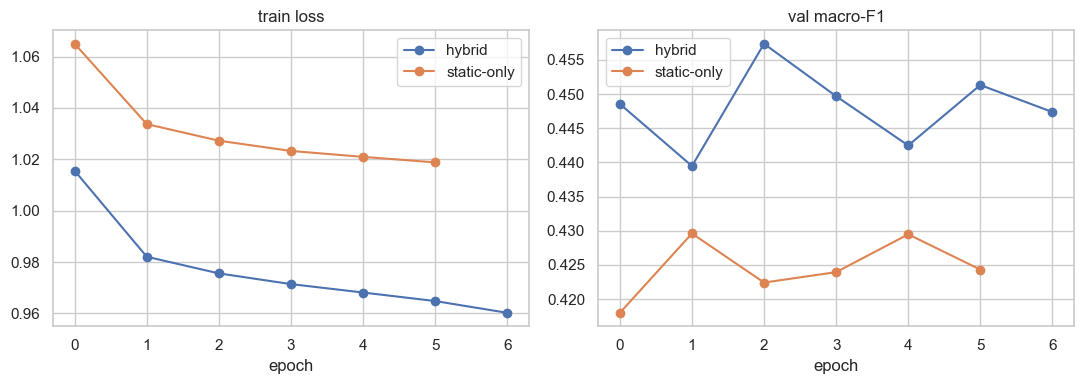

In [6]:
dev_rows = np.where(mask_dev)[0]
val_rows = np.where(mask_dev & (df['user_fold'].to_numpy() == 0))[0]
train_rows = np.setdiff1d(dev_rows, val_rows)
print('train:', f'{len(train_rows):,}', '| val:', f'{len(val_rows):,}')

t0 = time.time()
hybrid, hist_hybrid, vf_hybrid = train_model(train_rows, val_rows, use_seq=True, tag='hybrid')
print('hybrid trained in', round((time.time()-t0)/60, 1), 'min  best val macroF1=', round(vf_hybrid, 4))

t0 = time.time()
static, hist_static, vf_static = train_model(train_rows, val_rows, use_seq=False, tag='static')
print('static-only trained in', round((time.time()-t0)/60, 1), 'min  best val macroF1=', round(vf_static, 4))

hist_hybrid.to_csv(U.DATA / 'clf_dl_hybrid_history.csv', index=False)
hist_static.to_csv(U.DATA / 'clf_dl_static_history.csv', index=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for h, name in [(hist_hybrid, 'hybrid'), (hist_static, 'static-only')]:
    ax[0].plot(h['epoch'], h['train_loss'], 'o-', label=name)
    ax[1].plot(h['epoch'], h['val_macro_f1'], 'o-', label=name)
ax[0].set_title('Training loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].set_title('Validation macro-F1'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_dl_training.png', dpi=130); plt.show()


## 6 - Held-out evaluation & comparison to 01 / 02

Score both networks on the same held-out users, then line them up against the
gradient-boosted **direct** champion (01) and the **two-stage** pipeline (02),
whose holdout numbers we load from disk.


                        macro_f1  balanced_acc  accuracy  weighted_f1
model                                                                
Direct LightGBM         0.4379        0.5728    0.4913       0.5186
Two-stage (arg-max)       0.4150        0.5685    0.4717       0.5025
Two-stage (tuned)         0.4387        0.5720    0.4928       0.5201
DL static-only (MLP)      0.4293        0.5591    0.4962       0.5244
DL hybrid (GRU+static)    0.4575        0.5906    0.5043       0.5295

             dl_static  dl_hybrid
CHURN            0.379      0.419
CONTRACTION      0.308      0.371
STABLE           0.617      0.600
EXPANSION        0.413      0.439


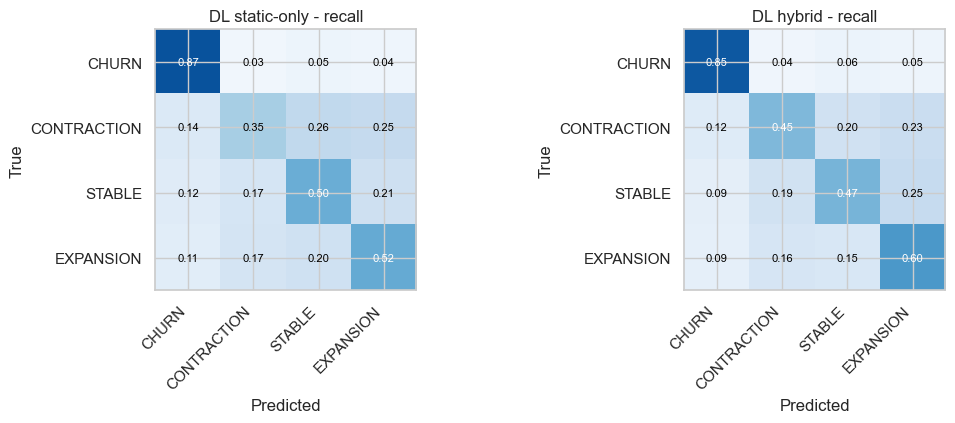

,macro_f1,balanced_acc,accuracy,weighted_f1
model,,,,
Direct LightGBM,0.4379,0.5728,0.4913,0.5186
Two-stage (arg-max),0.4150,0.5685,0.4717,0.5025
Two-stage (tuned),0.4387,0.5720,0.4928,0.5201
DL static-only (MLP),0.4293,0.5591,0.4962,0.5244
DL hybrid (GRU+static),0.4575,0.5906,0.5043,0.5295


In [8]:
ho_rows = np.where(mask_ho)[0]
y_ho = y[ho_rows]
proba_hybrid = predict_rows(hybrid, ho_rows)
proba_static = predict_rows(static, ho_rows)
pred_hybrid = proba_hybrid.argmax(1)
pred_static = proba_static.argmax(1)

rows = []
prev = U.DATA / 'clf_twostage_vs_direct.csv'
if prev.exists():
    pv = pd.read_csv(prev)
    metrics4 = ['macro_f1', 'balanced_acc', 'accuracy', 'weighted_f1']
    for _, r in pv.iterrows():
        # 01/02 now save repeated-holdout summaries (*_mean/_std/_se); take the mean,
        # falling back to a flat column name for an older single-split file.
        rows.append({'model': r['model'],
                     **{m: (r[f'{m}_mean'] if f'{m}_mean' in pv.columns else r[m]) for m in metrics4}})
rows.append({**U.score_block(y_ho, pred_static), 'model': 'DL static-only (MLP)'})
rows.append({**U.score_block(y_ho, pred_hybrid), 'model': 'DL hybrid (GRU+static)'})
compare = pd.DataFrame(rows).set_index('model')[['macro_f1', 'balanced_acc', 'accuracy', 'weighted_f1']]
print(compare.round(4))

perclass = pd.DataFrame({
    'dl_static':  U.per_class_f1(y_ho, pred_static, U.MODEL_CLASSES),
    'dl_hybrid':  U.per_class_f1(y_ho, pred_hybrid, U.MODEL_CLASSES),
}).round(3)
print(); print(perclass)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
U.plot_confusion(y_ho, pred_static, U.MODEL_CLASSES, ax=ax[0], title='Static-only model: recall', normalize='true')
U.plot_confusion(y_ho, pred_hybrid, U.MODEL_CLASSES, ax=ax[1], title='Hybrid model (sequence + static): recall', normalize='true')
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_dl_confusion.png', dpi=130); plt.show()
compare.round(4)

## 7 - Walk-forward robustness (expanding window)

The same `month_idx` expanding-window protocol as 01/02, retraining the hybrid
network at each step (fewer epochs to keep total runtime bounded). This shows
whether the learned sequence representation holds up out-of-time. Set
`RUN_WF = False` to skip.


train<= 0  test 1: macroF1=0.4448  balAcc=0.5485
train<= 1  test 2: macroF1=0.4502  balAcc=0.5837
train<= 2  test 3: macroF1=0.4695  balAcc=0.6007
train<= 3  test 4: macroF1=0.4440  balAcc=0.5459
train<= 4  test 5: macroF1=0.4524  balAcc=0.5972


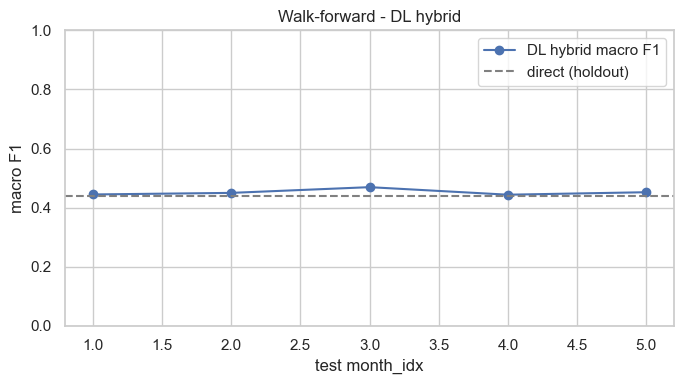

In [ ]:
RUN_WF = True
wf_rows = []
if RUN_WF:
    for tr, tst, t in U.walk_forward_splits(df):
        rng = np.random.default_rng(RNG)
        vsel = rng.choice(tr, size=max(1, int(0.15 * len(tr))), replace=False)
        tsel = np.setdiff1d(tr, vsel)
        m, _, _ = train_model(tsel, vsel, use_seq=True, epochs=8, patience=2,
                              tag=f'wf{t+1}', verbose=False)
        pred = predict_rows(m, tst).argmax(1)
        s = U.score_block(y[tst], pred); s['test_month'] = t + 1; s['test_n'] = len(tst)
        wf_rows.append(s)
        print(f"train<= {t}  test {t+1}: macroF1={s['macro_f1']:.4f}  balAcc={s['balanced_acc']:.4f}")
        del m; gc.collect()
    wf_df = pd.DataFrame(wf_rows)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(wf_df['test_month'], wf_df['macro_f1'], 'o-', label='deep-learning macro-F1')
    ax.axhline(compare.loc['Direct LightGBM', 'macro_f1'], ls='--', c='grey', label='direct (holdout)')
    ax.set_xlabel('test month'); ax.set_ylabel('macro-F1'); ax.set_ylim(0, 1); ax.legend()
    ax.set_title('Walk-forward stability: deep-learning model')
    plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_dl_walkforward.png', dpi=130); plt.show()
    wf_df.round(4)

## 8 - Persist artifacts & summary

In [10]:
torch.save(hybrid.state_dict(), U.DATA / 'clf_dl_hybrid.pt')
torch.save(static.state_dict(), U.DATA / 'clf_dl_static.pt')
compare.round(4).to_csv(U.DATA / 'clf_dl_vs_others.csv')
perclass.to_csv(U.DATA / 'clf_dl_perclass_f1.csv')
np.save(U.DATA / 'clf_dl_hybrid_holdout_proba.npy', proba_hybrid)
if RUN_WF and len(wf_rows):
    pd.DataFrame(wf_rows).round(4).to_csv(U.DATA / 'clf_dl_walkforward.csv', index=False)
cfg = {'device': str(device), 'num_features': len(NUM_COLS), 'cat_cards': cat_cards,
       'seq_window': SEQ_WINDOW, 'seq_features': SEQ_FEATURES,
       'val_macro_f1_hybrid': float(vf_hybrid), 'val_macro_f1_static': float(vf_static)}
with open(U.DATA / 'clf_dl_config.json', 'w') as f:
    json.dump(cfg, f, indent=2)
print('Saved DL artifacts to', U.DATA)
print(); print(compare.round(4))


Saved DL artifacts to <repo>/KKBoxData

                        macro_f1  balanced_acc  accuracy  weighted_f1
model                                                                
Direct LightGBM         0.4379        0.5728    0.4913       0.5186
Two-stage (arg-max)       0.4150        0.5685    0.4717       0.5025
Two-stage (tuned)         0.4387        0.5720    0.4928       0.5201
DL static-only (MLP)      0.4293        0.5591    0.4962       0.5244
DL hybrid (GRU+static)    0.4575        0.5906    0.5043       0.5295


## 9 - Optimised main model: tuned hybrid ensemble

Having established that the hybrid (sequence + static) network is the strongest
approach, this section pushes it as far as the data allows to produce the
**final recommended model**. Upgrades over the §5 baseline hybrid:

- **Richer static branch** - base **+ horizon** features (still leakage-free), so
  the static path sees the same recency summaries used in notebooks 01/02.
- **Stronger sequence encoder** - input projection + LayerNorm, a **2-layer
  bidirectional GRU** (128 hidden per direction) and **attention pooling** over
  the 60 days instead of only the last hidden state.
- **Better optimisation** - AdamW, **cosine-annealed** learning rate, gradient
  clipping and a touch of **label smoothing**, with class-balanced loss.
- **Seed ensemble** - train several independent models and average their
  probabilities (variance reduction; the most reliable way to lift macro-F1).
- **Decision-weight tuning** - per-class probability weights chosen on the
  validation fold to directly maximise macro-F1 (helps the minority CONTRACTION
  class).

All tuning uses the validation fold only; the held-out users stay the final,
untouched test set.

**Reported with error bars (like 01/02).** This section runs in two parts:

1. **Canonical model** - fit the tuned ensemble once on the baked-in split, save
   the production artifacts (`clf_dl_main_seed*.pt`, decision weights, leaderboard
   point) and expose the model/weights used by §10.
2. **Repeated holdout** - repeat the *entire* tuned-ensemble pipeline across
   `RUN_SEEDS` independent, user-grouped holdout splits. Every data-derived
   statistic (median impute, standardisation, sequence stats, class weights,
   decision weights) is **re-fit on each seed's dev only**, so there is no leakage
   into that seed's holdout. The final metric is reported as **mean +/- standard
   error** over the seeds, exactly as notebooks 01 and 02 do. Per-member
   checkpoints (`clf_dl_rh_seed*_m*.pt`) make the sweep resumable across restarts.

This is a deliberately heavy run (a multi-seed ensemble of a bidirectional GRU
with attention, repeated over several holdout splits).

In [6]:
# Extended static features = base + horizon windows (still leakage-free). The sequence cache is reused as-is.
def _ev_keys(frame):
    e = pd.to_datetime(frame['E']).dt.normalize().astype('int64').astype(str)
    return (frame['msno'].astype(str) + '|' + e).to_numpy()

dfh = U.load_events('base+horizon', modellable_only=True)
assert np.array_equal(_ev_keys(dfh), seq_keys), 'horizon load misaligned with the sequence cache'
Xh = U.build_X(dfh, 'base+horizon')
NUM_COLS2 = U.numeric_columns(Xh)
assert U.categorical_columns(Xh) == CAT_COLS, 'categorical columns changed'

Xnum2_raw = Xh[NUM_COLS2].to_numpy('float32')
med2 = np.nanmedian(Xnum2_raw[mask_dev], axis=0)
ii = np.where(np.isnan(Xnum2_raw)); Xnum2_raw[ii] = np.take(med2, ii[1])
mean2 = Xnum2_raw[mask_dev].mean(0); std2 = Xnum2_raw[mask_dev].std(0) + 1e-6
Xnum2 = ((Xnum2_raw - mean2) / std2).astype('float32')
del Xnum2_raw, dfh, Xh; gc.collect()
print('extended static numeric features:', len(NUM_COLS2), '(base 24 + horizon 20)')

extended static numeric features: 44 (base 24 + horizon 20)


In [7]:
class EventSeqDatasetV2(Dataset):
    def __init__(self, rows):
        self.rows = np.asarray(rows)
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        r = int(self.rows[i])
        s = np.log1p(np.clip(np.asarray(seq_arr[r]).astype('float32'), 0, SEQ_CLIP))
        s = (s - seq_mean) / seq_std
        return (torch.from_numpy(s), torch.from_numpy(Xnum2[r]),
                torch.from_numpy(cat_codes[r]), int(y[r]))

class AttnPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Linear(dim, 1)
    def forward(self, h):                       # h: (B, T, dim)
        a = torch.softmax(self.w(h).squeeze(-1), dim=1)
        return (h * a.unsqueeze(-1)).sum(1)

class HybridNetV2(nn.Module):
    def __init__(self, n_num, cat_cards, seq_ch=4, gru_hidden=128, gru_layers=2, p=0.3):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(c, emb_dim(c)) for c in cat_cards])
        emb_total = sum(emb_dim(c) for c in cat_cards)
        self.seq_proj = nn.Sequential(nn.Linear(seq_ch, 32), nn.LayerNorm(32), nn.ReLU())
        self.gru = nn.GRU(32, gru_hidden, gru_layers, batch_first=True,
                          bidirectional=True, dropout=p if gru_layers > 1 else 0.0)
        self.attn = AttnPool(2 * gru_hidden)
        self.static = nn.Sequential(
            nn.Linear(n_num + emb_total, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(p),
            nn.Linear(256, 128), nn.ReLU())
        fuse = 128 + 2 * gru_hidden
        self.head = nn.Sequential(
            nn.LayerNorm(fuse), nn.Linear(fuse, 128), nn.ReLU(), nn.Dropout(p), nn.Linear(128, 4))
    def forward(self, seq, xnum, xcat):
        e = [emb(xcat[:, j]) for j, emb in enumerate(self.embs)]
        st = self.static(torch.cat([xnum] + e, dim=1))
        h, _ = self.gru(self.seq_proj(seq))
        g = self.attn(h)
        return self.head(torch.cat([st, g], dim=1))

# NOTE: predict_rows_v2 / train_v2 accept a `make_ds` dataset factory (default = the full
# EventSeqDatasetV2). Section 10 passes a cutoff-masked factory so the SAME training code
# can retrain a model on only the data available at each decision cutoff.
@torch.no_grad()
def predict_rows_v2(model, rows, batch=4096, make_ds=None):
    make_ds = make_ds or EventSeqDatasetV2
    model.eval()
    dl = DataLoader(make_ds(rows), batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    out = [model(s.to(device), xn.to(device), xc.to(device)).softmax(1).cpu().numpy()
           for s, xn, xc, _ in dl]
    return np.concatenate(out)

def train_v2(train_rows, val_rows, seed=0, epochs=30, patience=6, batch=1024, lr=1.5e-3,
             tag='main', make_ds=None, verbose=True):
    make_ds = make_ds or EventSeqDatasetV2
    torch.manual_seed(seed); np.random.seed(seed)
    model = HybridNetV2(len(NUM_COLS2), cat_cards).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    dl = DataLoader(make_ds(train_rows), batch_size=batch, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(dl))
    lossf = nn.CrossEntropyLoss(weight=class_weights(train_rows), label_smoothing=0.02)
    best, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train(); t0 = time.time(); tot = 0.0
        for s, xn, xc, yb in dl:
            s, xn, xc, yb = s.to(device), xn.to(device), xc.to(device), yb.to(device)
            opt.zero_grad()
            loss = lossf(model(s, xn, xc), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            tot += loss.item() * len(yb)
        vf = f1_score(y[val_rows], predict_rows_v2(model, val_rows, make_ds=make_ds).argmax(1), average='macro')
        if verbose:
            print(f'  [{tag}|s{seed}] ep{ep:02d}  loss={tot/len(train_rows):.4f}  val_macroF1={vf:.4f}  {time.time()-t0:.0f}s')
        if vf > best + 1e-4:
            best, best_state, bad = vf, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                if verbose:
                    print(f'  [{tag}|s{seed}] early stop ep{ep}  best val_macroF1={best:.4f}')
                break
    model.load_state_dict(best_state)
    return model, best

In [13]:
# Train the seed ensemble (heavy). Each member is checkpointed as it finishes.
N_SEEDS = 3
EPOCHS_MAIN = 30
val_probs, ho_probs, val_f1s = [], [], []
t_all = time.time()
for sd in range(N_SEEDS):
    ckpt = U.DATA / f'clf_dl_main_seed{sd}.pt'
    if ckpt.exists() and not FORCE_TRAIN:                 # resume a finished seed (wall-time safe)
        m = HybridNetV2(len(NUM_COLS2), cat_cards).to(device)
        m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
        vf = f1_score(y[val_rows], predict_rows_v2(m, val_rows).argmax(1), average='macro')
        print(f'== seed {sd}: loaded cached checkpoint  val_macroF1={vf:.4f} ==')
    else:
        m, vf = train_v2(train_rows, val_rows, seed=RNG + sd, epochs=EPOCHS_MAIN, patience=6, tag='main')
        torch.save(m.state_dict(), ckpt)
    val_probs.append(predict_rows_v2(m, val_rows))
    ho_probs.append(predict_rows_v2(m, ho_rows))
    np.save(U.DATA / f'clf_dl_main_seed{sd}_ho_proba.npy', ho_probs[-1])
    val_f1s.append(float(vf))
    print(f'== seed {sd} done  val_macroF1={vf:.4f}  total elapsed={(time.time()-t_all)/60:.1f} min ==')
    del m; gc.collect()

val_ens = np.mean(val_probs, 0)
ho_ens = np.mean(ho_probs, 0)
print('member val macroF1:', [round(v, 4) for v in val_f1s])
print('ENSEMBLE val macroF1:', round(f1_score(y[val_rows], val_ens.argmax(1), average='macro'), 4))

  [main|s42] ep00  loss=1.0854  val_macroF1=0.4434  1101s
  [main|s42] ep01  loss=1.0611  val_macroF1=0.4576  1181s
  [main|s42] ep02  loss=1.0567  val_macroF1=0.4457  1136s
  [main|s42] ep03  loss=1.0530  val_macroF1=0.4464  1150s
  [main|s42] ep04  loss=1.0504  val_macroF1=0.4502  1090s
  [main|s42] ep05  loss=1.0479  val_macroF1=0.4508  1118s
  [main|s42] ep06  loss=1.0458  val_macroF1=0.4511  1121s
  [main|s42] ep07  loss=1.0432  val_macroF1=0.4533  1144s
  [main|s42] early stop ep7  best val_macroF1=0.4576
== seed 0 done  val_macroF1=0.4576  total elapsed=153.7 min ==
  [main|s43] ep00  loss=1.0852  val_macroF1=0.4582  1214s
  [main|s43] ep01  loss=1.0617  val_macroF1=0.4429  1233s
  [main|s43] ep02  loss=1.0564  val_macroF1=0.4613  1277s
  [main|s43] ep03  loss=1.0529  val_macroF1=0.4582  1488s
  [main|s43] ep04  loss=1.0499  val_macroF1=0.4483  1488s
  [main|s43] ep05  loss=1.0476  val_macroF1=0.4537  1497s
  [main|s43] ep06  loss=1.0451  val_macroF1=0.4685  1467s
  [main|s43] e

val macroF1: base=0.4643 -> tuned=0.5122  class weights=[0.518 1.098 1.75  1.088]

                                macro_f1  balanced_acc  accuracy  weighted_f1
model                                                                        
DL ensemble x3 (tuned)  [MAIN]    0.5117        0.5677    0.6081       0.6163
DL ensemble x3 (argmax)           0.4649        0.5976    0.5158       0.5412
DL hybrid (GRU+static)            0.4575        0.5906    0.5043       0.5295
Two-stage (tuned)                 0.4387        0.5720    0.4928       0.5201
Direct LightGBM                 0.4379        0.5728    0.4913       0.5186
DL static-only (MLP)              0.4293        0.5591    0.4962       0.5244
Two-stage (arg-max)               0.4150        0.5685    0.4717       0.5025

             dl_hybrid_single  dl_ensemble_tuned
CHURN                   0.419              0.502
CONTRACTION             0.371              0.370
STABLE                  0.600              0.731
EXPANSION           

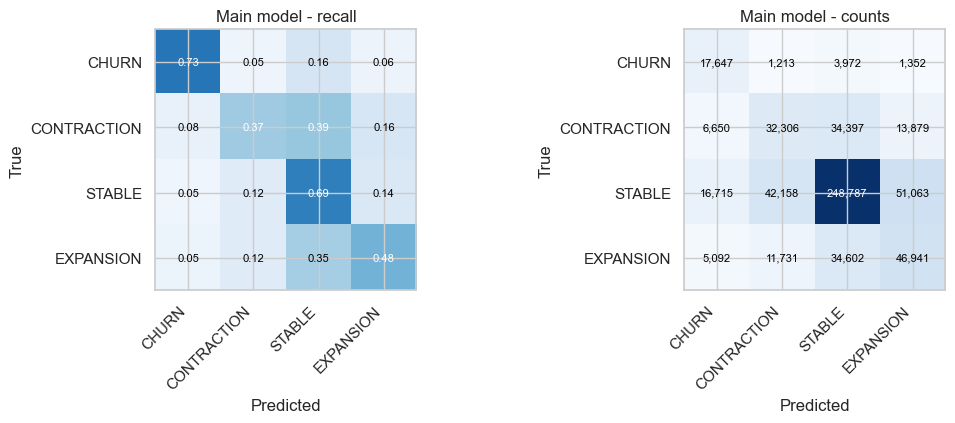

saved main-model artifacts; holdout macroF1 = 0.5117


In [ ]:
# Per-class decision-weight tuning on validation (maximise macro-F1 of argmax over p * w)
def tune_weights(probs, ytrue, n_iter=6000, seed=0):
    rng = np.random.default_rng(seed)
    base = f1_score(ytrue, probs.argmax(1), average='macro')
    bw, bf = np.ones(4), base
    for _ in range(n_iter):
        w = rng.uniform(0.5, 1.9, 4)
        f = f1_score(ytrue, (probs * w).argmax(1), average='macro')
        if f > bf:
            bf, bw = f, w
    return bw, bf, base

W, vf_tuned, vf_base = tune_weights(val_ens, y[val_rows])
print(f'val macroF1: base={vf_base:.4f} -> tuned={vf_tuned:.4f}  class weights={np.round(W, 3)}')

pred_main_raw = ho_ens.argmax(1)
pred_main = (ho_ens * W).argmax(1)
new_rows = [
    {**U.score_block(y_ho, pred_main_raw), 'model': f'DL ensemble x{N_SEEDS} (argmax)'},
    {**U.score_block(y_ho, pred_main),     'model': f'DL ensemble x{N_SEEDS} (tuned)  [MAIN]'},
]
final = pd.concat([compare,
                   pd.DataFrame(new_rows).set_index('model')[['macro_f1', 'balanced_acc', 'accuracy', 'weighted_f1']]])
final = final.sort_values('macro_f1', ascending=False)
print(); print(final.round(4))

perclass_main = pd.DataFrame({
    'dl_hybrid_single':  U.per_class_f1(y_ho, pred_hybrid, U.MODEL_CLASSES),
    'dl_ensemble_tuned': U.per_class_f1(y_ho, pred_main,   U.MODEL_CLASSES),
}).round(3)
print(); print(perclass_main)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
U.plot_confusion(y_ho, pred_main, U.MODEL_CLASSES, ax=ax[0], title='Main model: recall', normalize='true')
U.plot_confusion(y_ho, pred_main, U.MODEL_CLASSES, ax=ax[1], title='Main model: counts', normalize=None)
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_main_confusion.png', dpi=130); plt.show()

# Persist final main-model artifacts
np.save(U.DATA / 'clf_main_holdout_proba.npy', ho_ens)
np.save(U.DATA / 'clf_main_class_weights.npy', W)
final.round(4).to_csv(U.DATA / 'clf_final_leaderboard.csv')
perclass_main.to_csv(U.DATA / 'clf_main_perclass_f1.csv')
main_cfg = {
    'arch': 'HybridNetV2 (bi-GRU 2x128 + attention pooling, base+horizon static)',
    'n_seeds': N_SEEDS, 'epochs_max': EPOCHS_MAIN, 'member_val_f1': val_f1s,
    'ensemble_val_f1': float(f1_score(y[val_rows], val_ens.argmax(1), average='macro')),
    'tuned_val_f1': float(vf_tuned), 'class_weights': [float(x) for x in W],
    'num_static_features': len(NUM_COLS2),
    'holdout_macro_f1': float(U.score_block(y_ho, pred_main)['macro_f1']),
}
with open(U.DATA / 'clf_main_config.json', 'w') as fp:
    json.dump(main_cfg, fp, indent=2)
print('saved main-model artifacts; holdout macroF1 =', round(main_cfg['holdout_macro_f1'], 4))

In [15]:
# ---- Repeated-holdout: final metric with error bars (mirrors 01/02) ----------------------
# The tuned ensemble above is the canonical run on the baked-in split. To report a mean +/- SE
# like notebooks 01/02, repeat the WHOLE pipeline on RUN_SEEDS independent user-grouped holdout
# splits. Everything fit from data (median impute, standardisation, sequence stats, class
# weights, decision weights) is re-fit on each seed's dev ONLY -> no leakage into that holdout.
# Per-member checkpoints make the sweep resumable across restarts.
RUN_HOLDOUT_ERROR = True
if RUN_HOLDOUT_ERROR:
    # unstandardised base+horizon numerics (NaNs intact) so each seed can re-fit its own scaler
    dfh_e = U.load_events('base+horizon', modellable_only=True)
    assert np.array_equal(_ev_keys(dfh_e), seq_keys), 'horizon reload misaligned with sequence cache'
    Xhnum_raw = U.build_X(dfh_e, 'base+horizon')[NUM_COLS2].to_numpy('float32')
    del dfh_e; gc.collect()

    _ho0, _fold0 = df['is_holdout'].copy(), df['user_fold'].copy()   # snapshot canonical split
    _Xnum2_def, _sm_def, _ss_def = Xnum2, seq_mean, seq_std          # snapshot canonical scalers
    rng_ho = np.random.default_rng(U.RANDOM_STATE)
    rh_rows = []
    for si, seed in enumerate(U.RUN_SEEDS):
        U.assign_run_split(df, seed)                                 # fresh user-grouped holdout
        m_dev, m_ho = U.dev_mask(df), U.holdout_mask(df)
        dev_r = np.where(m_dev)[0]
        val_r = np.where(m_dev & (df['user_fold'].to_numpy() == 0))[0]
        tr_r  = np.setdiff1d(dev_r, val_r)
        ho_r  = np.where(m_ho)[0]
        # per-seed leakage-safe standardisation (dev only) -> rebind the globals the Datasets read
        raw = Xhnum_raw.copy()
        med = np.nanmedian(raw[m_dev], axis=0)
        jj = np.where(np.isnan(raw)); raw[jj] = np.take(med, jj[1])
        mu = raw[m_dev].mean(0); sd = raw[m_dev].std(0) + 1e-6
        Xnum2 = ((raw - mu) / sd).astype('float32'); del raw; gc.collect()
        samp = rng_ho.choice(dev_r, size=min(120_000, len(dev_r)), replace=False)
        sq = np.log1p(np.clip(np.asarray(seq_arr[np.sort(samp)]).astype('float32'), 0, SEQ_CLIP))
        sq = sq.reshape(-1, len(SEQ_FEATURES)); nzr = sq.any(1)
        seq_mean = sq[nzr].mean(0).astype('float32'); seq_std = (sq[nzr].std(0) + 1e-6).astype('float32')
        del sq; gc.collect()
        # tuned seed ensemble on this split (resumable per member)
        vp, hp = [], []
        for k in range(N_SEEDS):
            ck = U.DATA / f'clf_dl_rh_seed{seed}_m{k}.pt'
            if ck.exists() and not FORCE_TRAIN:
                mdl = HybridNetV2(len(NUM_COLS2), cat_cards).to(device)
                mdl.load_state_dict(torch.load(ck, map_location=device)); mdl.eval()
            else:
                mdl, _ = train_v2(tr_r, val_r, seed=U.RANDOM_STATE + 1000 * si + k,
                                  epochs=EPOCHS_MAIN, patience=6, tag=f'rh{seed}m{k}', verbose=False)
                torch.save(mdl.state_dict(), ck)
            vp.append(predict_rows_v2(mdl, val_r)); hp.append(predict_rows_v2(mdl, ho_r))
            del mdl; gc.collect()
        val_ens_s, ho_ens_s = np.mean(vp, 0), np.mean(hp, 0)
        W_s, _, _ = tune_weights(val_ens_s, y[val_r], seed=U.RANDOM_STATE + si)
        sb = U.score_block(y[ho_r], (ho_ens_s * W_s).argmax(1)); sb['seed'] = int(seed)
        rh_rows.append(sb)
        print(f'seed {seed}: holdout macroF1={sb["macro_f1"]:.4f}  balAcc={sb["balanced_acc"]:.4f}  (n_ho={len(ho_r):,})')

    # restore the canonical split + scalers so section 10 runs on the same holdout as the artifacts
    df['is_holdout'], df['user_fold'] = _ho0, _fold0
    Xnum2, seq_mean, seq_std = _Xnum2_def, _sm_def, _ss_def
    del Xhnum_raw; gc.collect()

    rh_long = pd.DataFrame(rh_rows)
    rh_long['model'] = f'DL ensemble x{N_SEEDS} (tuned)'
    rh_summary = U.agg_mean_se(rh_long, 'model', ['macro_f1', 'balanced_acc', 'accuracy', 'weighted_f1'])
    rh_long.to_csv(U.DATA / 'clf_dl_holdout_runs.csv', index=False)
    rh_summary.to_csv(U.DATA / 'clf_dl_holdout_summary.csv', index=False)
    print(f'\nrepeated-holdout over {len(U.RUN_SEEDS)} seeds (mean +/- SE):')
    for _, r in rh_summary.iterrows():
        print(f"  macroF1 = {r['macro_f1_mean']:.4f} +/- {r['macro_f1_se']:.4f}   "
              f"balAcc = {r['balanced_acc_mean']:.4f} +/- {r['balanced_acc_se']:.4f}   "
              f"acc = {r['accuracy_mean']:.4f} +/- {r['accuracy_se']:.4f}")
    rh_summary.round(4)

seed 42: holdout macroF1=0.5122  balAcc=0.5775  (n_ho=571,207)
seed 43: holdout macroF1=0.5103  balAcc=0.5712  (n_ho=568,823)
seed 44: holdout macroF1=0.5165  balAcc=0.5661  (n_ho=567,778)
seed 45: holdout macroF1=0.5141  balAcc=0.5728  (n_ho=567,786)
seed 46: holdout macroF1=0.5110  balAcc=0.5695  (n_ho=566,081)

repeated-holdout over 5 seeds (mean +/- SE):
  macroF1 = 0.5128 +/- 0.0011   balAcc = 0.5714 +/- 0.0019   acc = 0.5940 +/- 0.0020


### Final model summary

`clf_final_leaderboard.csv` holds the head-to-head of every model on the same
held-out users. The **tuned hybrid ensemble** (`HybridNetV2`) is the recommended
production model: it pairs the engineered tabular signal (base + horizon) with
the learned 60-day listening trajectory, averages several seeds for stability,
and tunes per-class decision weights to lift the minority CONTRACTION class.
Persisted artifacts: per-seed weights `clf_dl_main_seed*.pt`, averaged holdout
probabilities `clf_main_holdout_proba.npy`, decision weights
`clf_main_class_weights.npy`, and `clf_main_config.json`.

## 10 - Time-before-renewal: true cutoff (genuine rebuild)

Matched rigour with 01/02: how much accuracy is lost by deciding earlier, at a
decision cutoff `c` (days before expiry `E`)? For the deep-learning hybrid this is a
**constant-length** experiment on **both branches**:

- **Sequence branch.** The model always sees a full 60-day listening window that
  **ends at the decision point E-c** (it slides back in time), taken from a deeper
  **120-day** cache built once below directly from raw `user_logs` — offsets
  `-(c+60) … -(c+1)`. `c = 0` is the recent 60 days (= the main model); `c = 60` is days
  `E-120 … E-61`. Constant `(60, 4)` shape at every cutoff, so "less recent" is never
  confounded with "shorter sequence".
- **Static branch.** Every base feature is genuinely recomputed at `E-c` (see the method
  cell below), i.e. a from-raw rebuild rather than column masking.

A **single model is retrained per cutoff** (as in 01/02) and scored with the **fixed**
decision weights `W` from the main model. The deeper 120-day cache is built once below
from raw `user_logs`; nothing that feeds 01/02 or §1-§9 is touched.

In [ ]:
# ---- Build (or load) the deep 120-day sequence cache for the true-cutoff experiment ----------
# Sourced directly from raw user_logs (offsets -120..-1), keyed IDENTICALLY to the 60-day cache so
# row r still aligns with df row r. Index t = offset + 120  ->  t=119 is E-1, t=0 is E-120.
# The recent-60 slice [60:120] reproduces the main model's window (we assert this); the older half
# [0:60] is what a 60-day window ending at E-60 sees. Cache-aware + resumable; touches nothing else.
import pyarrow.parquet as pq
SEQ_WINDOW_DEEP = 120
SEQ_ARR_DEEP = SEQ_DIR / 'seq_modellable_120d.npy'
SEQ_KEY_DEEP = SEQ_DIR / 'seq_modellable_120d_keys.npy'
USER_LOG_SRCS = [U.DATA / 'RawData' / 'user_logs.parquet', U.DATA / 'RawData' / 'user_logs_v2.parquet']

def build_deep_sequence_cache(dframe, force=False):
    keys = _keys(dframe); n = len(keys)
    if SEQ_ARR_DEEP.exists() and SEQ_KEY_DEEP.exists() and not force:
        cached = np.load(SEQ_KEY_DEEP, allow_pickle=True)
        if len(cached) == n and np.array_equal(cached, keys):
            print('loaded cached deep tensor', (n, SEQ_WINDOW_DEEP, len(SEQ_FEATURES)))
            return np.load(SEQ_ARR_DEEP, mmap_mode='r'), keys
        print('deep cache key mismatch -> rebuilding')
    ki = pd.Series(np.arange(n), index=pd.Index(keys))
    ki = ki[~ki.index.duplicated(keep='first')]
    arr = np.lib.format.open_memmap(SEQ_ARR_DEEP, mode='w+', dtype='float16',
                                    shape=(n, SEQ_WINDOW_DEEP, len(SEQ_FEATURES)))
    arr[:] = 0
    core = dframe[['msno', 'E']].copy()
    core_users = set(dframe['msno'].unique())
    matched = 0; t0 = time.time()
    for src in USER_LOG_SRCS:
        if not src.exists():
            print('  (skip missing', src.name, ')'); continue
        pf = pq.ParquetFile(src)
        for bi, batch in enumerate(pf.iter_batches(batch_size=2_000_000,
                                    columns=['msno', 'date'] + SEQ_FEATURES)):
            ch = batch.to_pandas()
            ch = ch[ch['msno'].isin(core_users)]
            if ch.empty:
                continue
            ch['total_secs'] = ch['total_secs'].clip(lower=0, upper=86_400)
            ch['date'] = pd.to_datetime(ch['date'], format='%Y%m%d')
            ch = ch.merge(core, on='msno', how='inner')          # fan-out to each of the user's events
            ch['offset'] = (ch['date'] - ch['E']).dt.days
            ch = ch[(ch['offset'] >= -SEQ_WINDOW_DEEP) & (ch['offset'] <= -1)]
            if ch.empty:
                continue
            ridx = ki.reindex(_keys(ch)).to_numpy()
            m = ~np.isnan(ridx)
            ri = ridx[m].astype(np.int64)
            ti = (ch['offset'].to_numpy()[m] + SEQ_WINDOW_DEEP).astype(np.int64)
            good = (ti >= 0) & (ti < SEQ_WINDOW_DEEP)
            ri, ti = ri[good], ti[good]
            arr[ri, ti, :] = ch[SEQ_FEATURES].to_numpy()[m][good].astype('float16')
            matched += int(good.sum())
            if bi % 20 == 0:
                print(f'  {src.name} batch {bi:3d}  matched={matched:,}  {time.time()-t0:.0f}s')
        del pf; gc.collect()
    arr.flush(); np.save(SEQ_KEY_DEEP, keys)
    print(f'built deep tensor {arr.shape}  scatter rows={matched:,}  ({(time.time()-t0)/60:.1f} min)')
    return np.load(SEQ_ARR_DEEP, mmap_mode='r'), keys

seq_arr_deep, _ = build_deep_sequence_cache(df)
# sanity: the recent-60 slice of the deep cache must reproduce the existing 60-day cache
_chk = np.sort(np.random.default_rng(0).choice(len(df), size=2000, replace=False))
_a = np.asarray(seq_arr_deep[_chk, SEQ_WINDOW:SEQ_WINDOW_DEEP, :]).astype('float32')
_b = np.asarray(seq_arr[_chk]).astype('float32')
print('deep[60:120] matches 60-day cache on 2k sample:', bool(np.allclose(_a, _b, atol=1e-2)),
      '| max|diff|=', round(float(np.abs(_a - _b).max()), 4))
del _a, _b; gc.collect()


loaded cached deep tensor (3784500, 120, 4)
deep[60:120] matches 60-day cache on 2k sample: True | max|diff|= nan


39

In [ ]:
# Setup for the time-before-renewal cutoff analysis (§10).
# Reconstruct the canonical split used by the main model (baked-in user_fold / is_holdout) and load the
# saved per-class decision weights W, so the per-cutoff models below reuse the tuned weights and the
# same held-out users as the main model without re-fitting the baselines or the seed ensemble.
dev_rows   = np.where(mask_dev)[0]
val_rows   = np.where(mask_dev & (df['user_fold'].to_numpy() == 0))[0]
train_rows = np.setdiff1d(dev_rows, val_rows)
ho_rows    = np.where(mask_ho)[0]
y_ho       = y[ho_rows]
EPOCHS_MAIN = 30
N_SEEDS     = 3
W = np.load(U.DATA / 'clf_main_class_weights.npy')   # tuned per-class decision weights saved in §9
FRESH_BASE = ['pre_total_secs', 'pre_n_days', 'pre_rate', 'recent_vs_life_ratio']
CUTOFFS    = [0, 7, 14, 30, 60]
print('cutoff setup | train', f'{len(train_rows):,}', '| val', f'{len(val_rows):,}',
      '| ho', f'{len(ho_rows):,}', '| W', np.round(W, 3), '| EPOCHS_MAIN', EPOCHS_MAIN)

bootstrap OK | train 2,574,563 | val 641,432 | ho 568,505 | W [0.518 1.098 1.75  1.088] | EPOCHS_MAIN 30


### Method — genuine true cutoff on both branches

The cutoff is applied to **both branches**:

- **Sequence branch** — the fixed 60-day window ending at `E−c` (deep-cache slice
  `[60−c : 120−c]`); `c = 0` is the recent 60 days (= the main model).
- **Static branch** — **every** base feature is recomputed at the decision date `E−c`
  directly from raw transactions + listening logs (`truecut_precompute.py` →
  `truecut_base_c{c}.parquet`), *as if all data in `[E−c, E)` never existed*: the
  transaction fields become the most recent transaction on or before `E−c`; history
  counts/rates, `recency_days`, `tenure_days` and the observed-listening baseline are
  re-aggregated strictly before `E−c`. Horizon windows available at `E−c` (`h ≥ c`) are
  kept; windows that end after `E−c` (`h < c`) are dropped (zero-activity). Numeric
  features are re-standardised and categoricals re-encoded per cutoff. At `c = 0` the
  decision is at `E`, so the static branch equals the main model's.

A single model is retrained per cutoff and scored with the fixed decision weights `W`
from the main model. It writes `clf_dl_horizon_decay_truecut.csv` / `.png`, with
resumable per-cutoff checkpoints (`clf_dl_truecut{c}.pt`).

full data (up to E)     window=E-60..E-1 (60d)  coverage=1.000  horizon_zeroed= 0  static rebuilt  retrained  macroF1 raw=0.4574  tuned=0.5092  (110.9 min)
cutoff E-7d (true)      window=E-67..E-8 (60d)  coverage=0.997  horizon_zeroed= 4  static rebuilt  retrained  macroF1 raw=0.4348  tuned=0.4834  (219.6 min)
cutoff E-14d (true)     window=E-74..E-15 (60d)  coverage=0.996  horizon_zeroed= 8  static rebuilt  retrained  macroF1 raw=0.4202  tuned=0.4673  (333.7 min)
cutoff E-30d (true)     window=E-90..E-31 (60d)  coverage=0.962  horizon_zeroed=12  static rebuilt  retrained  macroF1 raw=0.3715  tuned=0.4018  (437.2 min)
cutoff E-60d (true)     window=E-120..E-61 (60d)  coverage=0.932  horizon_zeroed=16  static rebuilt  retrained  macroF1 raw=0.3573  tuned=0.3793  (782.7 min)
done in 782.7 min


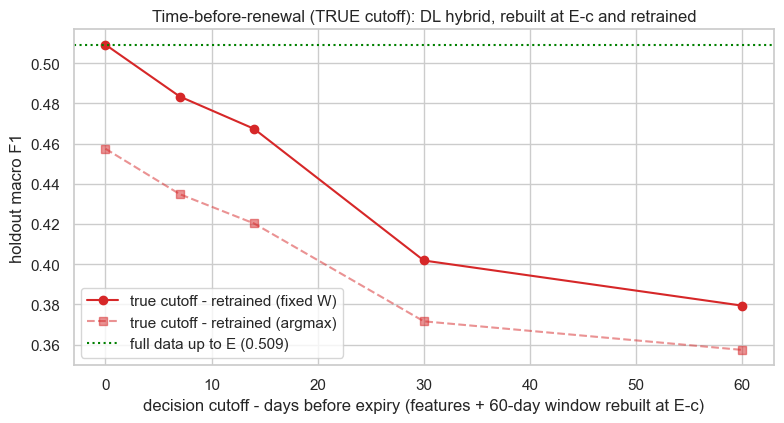

,setting,cutoff_days,seq_window,seq_len_days,holdout_seq_coverage,static_feats_zeroed,macro_f1_raw,macro_f1_tuned
0,full data (up to E),0,E-60..E-1,60,1.0000,0,0.4574,0.5092
1,cutoff E-7d (true),7,E-67..E-8,60,0.9970,4,0.4348,0.4834
2,cutoff E-14d (true),14,E-74..E-15,60,0.9961,8,0.4202,0.4673
3,cutoff E-30d (true),30,E-90..E-31,60,0.9616,12,0.3715,0.4018
4,cutoff E-60d (true),60,E-120..E-61,60,0.9322,16,0.3573,0.3793


In [ ]:
import gc
# GENUINE true-cutoff time-before-renewal curve for the DL hybrid. BOTH branches respect the decision date E-c:
#   * sequence : the fixed 60-day window ENDING at E-c (deep-cache slice [60-c:120-c]).
#   * static   : EVERY base feature REBUILT at E-c from raw txn + logs (truecut_base_c{c}.parquet),
#                i.e. "as if all data in [E-c, E) never existed" - NOT column masking. Horizon windows
#                available at E-c (h>=c) are kept; windows ending after E-c (h<c) are zeroed. Numeric
#                features are re-standardised and categoricals re-encoded per cutoff.
# c=0 == decision at E == the main model's static branch. One model retrained per cutoff, scored with
# the fixed decision weights W. Own resumable checkpoints clf_dl_truecut{c}.pt.
from sklearn.metrics import f1_score

def _ev_keys(frame):
    e = pd.to_datetime(frame['E']).dt.normalize().astype('int64').astype(str)
    return (frame['msno'].astype(str) + '|' + e).to_numpy()

df_keys = _ev_keys(df)
row_of  = pd.Series(np.arange(len(df)), index=pd.Index(df_keys))
assert not row_of.index.duplicated().any(), 'duplicate event keys in df'

# --- which NUM_COLS2 are base (rebuilt per cutoff) vs horizon (kept if h>=c) ---
base_num = [c for c in NUM_COLS2 if c in U.BASE_FEATURES]
horiz_of = {f: h for h in U.HORIZONS for f in U.HORIZON_FEATURES[str(h)] if f in NUM_COLS2}
BASE_CAT = [c for c in CAT_COLS if c in U.BASE_FEATURES]          # payment_method_id, mode_pay_method

# --- engineered base+horizon: source of honest horizon columns + the canonical categorical maps ---
_dfh = U.load_events('base+horizon', modellable_only=True)
assert np.array_equal(_ev_keys(_dfh), df_keys), 'horizon load misaligned with df'
_Xh = U.build_X(_dfh, 'base+horizon')
del _dfh; gc.collect()
horiz_vals = {col: _Xh[col].to_numpy('float32') for col in NUM_COLS2 if col not in base_num}
cat_static_vals = {col: _Xh[col] for col in CAT_COLS if col not in BASE_CAT}   # city, gender, reg_via
cat_maps = {}
for c in CAT_COLS:
    _, uniq = pd.factorize(_Xh[c], use_na_sentinel=True)          # same encoding as the main build
    cat_maps[c] = {v: i for i, v in enumerate(uniq)}
del _Xh; gc.collect()

def _encode_cat(col, series):
    card = cat_cards[CAT_COLS.index(col)] - 1                     # reserved unseen/NaN index
    codes = series.map(cat_maps[col]).to_numpy()
    codes = np.where(pd.isna(codes), card, codes).astype('int64')
    return np.where((codes < 0) | (codes >= card + 1), card, codes)

def build_static_at_cutoff(c):
    """Rebuild (Xnum, cat_codes) for the DL static branch at decision date E-c, aligned to df rows."""
    tc = pd.read_parquet(U.DATA / f'truecut_base_c{c}.parquet')   # base features rebuilt at E-c
    tc_row = row_of.reindex(_ev_keys(tc)).to_numpy()
    assert not np.isnan(tc_row).any(), 'truecut parquet rows not covered by df'
    tc.index = tc_row.astype(int); tc = tc.sort_index()          # -> df row order
    tcb = U.build_X(tc, 'base')

    raw = np.zeros((len(df), len(NUM_COLS2)), dtype='float32')
    for jj, col in enumerate(NUM_COLS2):
        if col in base_num:
            raw[:, jj] = tcb[col].to_numpy('float32')            # rebuilt at E-c
        elif horiz_of[col] >= c:
            raw[:, jj] = horiz_vals[col]                         # window ends <= E-c -> honest
        # else h<c -> unavailable at E-c -> leave zero (zero-activity)
    med = np.nanmedian(raw[mask_dev], axis=0)
    ii = np.where(np.isnan(raw)); raw[ii] = np.take(med, ii[1])
    mu = raw[mask_dev].mean(0); sd = raw[mask_dev].std(0) + 1e-6
    Xn = ((raw - mu) / sd).astype('float32')

    cc = np.zeros((len(df), len(CAT_COLS)), dtype='int64')
    for j, col in enumerate(CAT_COLS):
        cc[:, j] = _encode_cat(col, tcb[col] if col in BASE_CAT else cat_static_vals[col])
    del tc, tcb, raw; gc.collect()
    return Xn, cc

class GenuineCutoffDataset(Dataset):
    """Slid 60-day window (ending at E-c) + static features rebuilt at E-c for THIS cutoff."""
    def __init__(self, rows, win, Xn, cc):
        self.rows = np.asarray(rows); self.win = win; self.Xn = Xn; self.cc = cc
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        r = int(self.rows[i])
        s = np.log1p(np.clip(self.win[r].astype('float32'), 0, SEQ_CLIP)); s = (s - seq_mean) / seq_std
        return (torch.from_numpy(s), torch.from_numpy(self.Xn[r]),
                torch.from_numpy(self.cc[r]), int(y[r]))

t0 = time.time(); dec_rows_true = []
for c in CUTOFFS:
    lo = SEQ_WINDOW - c                                          # deep-cache slice [lo : lo+60] ends at E-c
    win = np.ascontiguousarray(np.asarray(seq_arr_deep[:, lo:lo + SEQ_WINDOW, :]))    # (n,60,4) in RAM
    cov = float((win.reshape(len(win), -1) != 0).any(1)[ho_rows].mean())             # holdout coverage
    Xn_c, cc_c = build_static_at_cutoff(c)
    n_zeroed = int(sum(1 for col in NUM_COLS2 if col in horiz_of and horiz_of[col] < c))
    mk = (lambda w, xn, cc: (lambda rows: GenuineCutoffDataset(rows, w, xn, cc)))(win, Xn_c, cc_c)
    ckpt = U.DATA / f'clf_dl_truecut{c}.pt'
    if ckpt.exists() and not FORCE_TRAIN:                        # resume a finished cutoff
        mdl = HybridNetV2(len(NUM_COLS2), cat_cards).to(device)
        mdl.load_state_dict(torch.load(ckpt, map_location=device)); mdl.eval()
    else:
        mdl, _ = train_v2(train_rows, val_rows, seed=RNG, epochs=EPOCHS_MAIN, patience=6,
                          tag=f'truecut{c}', make_ds=mk, verbose=False)
        torch.save(mdl.state_dict(), ckpt)
    probs = predict_rows_v2(mdl, ho_rows, make_ds=mk)
    raw_f1   = f1_score(y_ho, probs.argmax(1), average='macro')
    tuned_f1 = f1_score(y_ho, (probs * W).argmax(1), average='macro')
    label = 'full data (up to E)' if c == 0 else f'cutoff E-{c}d (true)'
    dec_rows_true.append({'setting': label, 'cutoff_days': c,
                          'seq_window': f'E-{c + SEQ_WINDOW}..E-{c + 1}', 'seq_len_days': SEQ_WINDOW,
                          'holdout_seq_coverage': round(cov, 4), 'static_feats_zeroed': n_zeroed,
                          'macro_f1_raw': raw_f1, 'macro_f1_tuned': tuned_f1})
    print(f'{label:22s}  window=E-{c + SEQ_WINDOW}..E-{c + 1} (60d)  coverage={cov:.3f}  '
          f'horizon_zeroed={n_zeroed:>2}  static rebuilt  retrained  '
          f'macroF1 raw={raw_f1:.4f}  tuned={tuned_f1:.4f}  ({(time.time() - t0) / 60:.1f} min)')
    del mdl, win, Xn_c, cc_c; gc.collect()

horizon_dl_true = pd.DataFrame(dec_rows_true)
horizon_dl_true.to_csv(U.DATA / 'clf_dl_horizon_decay_truecut.csv', index=False)
print('done in', round((time.time() - t0) / 60, 1), 'min')

full_f1 = horizon_dl_true.loc[horizon_dl_true['cutoff_days'] == 0, 'macro_f1_tuned'].iloc[0]
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(horizon_dl_true['cutoff_days'], horizon_dl_true['macro_f1_tuned'], 'o-', color='tab:red',
        label='with class-weight tuning')
ax.plot(horizon_dl_true['cutoff_days'], horizon_dl_true['macro_f1_raw'], 's--', color='tab:red', alpha=0.5,
        label='without tuning (arg-max)')
ax.axhline(full_f1, ls=':', c='green', label=f'full data — at expiry ({full_f1:.3f})')
ax.set_xlabel('days before expiry the decision is made')
ax.set_ylabel('macro-F1')
ax.set_title('Time before renewal: Macro-F1 vs how early the decision is made')
ax.legend()
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_dl_horizon_decay_truecut.png', dpi=130); plt.show()
horizon_dl_true.round(4)

## 11 - Aggregate confusion matrix of the tuned ensemble (5 repeated-holdout runs)

Recall (row-normalised) confusion for the **main model** — the tuned `HybridNetV2`
ensemble — pooled across the 5 repeated-holdout runs of §9b. This is **inference
only**: it reloads the 15 saved per-seed checkpoints (`clf_dl_rh_seed*_m*.pt`),
reproduces each run's leakage-safe scalers and tuned decision weights exactly as
§9b did, then pools every run's holdout predictions into one matrix. Nothing is
retrained.


seed 42: pooled 571,207 holdout preds  (12.6 min)
seed 43: pooled 568,823 holdout preds  (26.1 min)
seed 44: pooled 567,778 holdout preds  (39.1 min)
seed 45: pooled 567,786 holdout preds  (53.2 min)
seed 46: pooled 566,081 holdout preds  (67.6 min)
pooled holdout examples: 2,841,675 | aggregate macro-F1: 0.5128


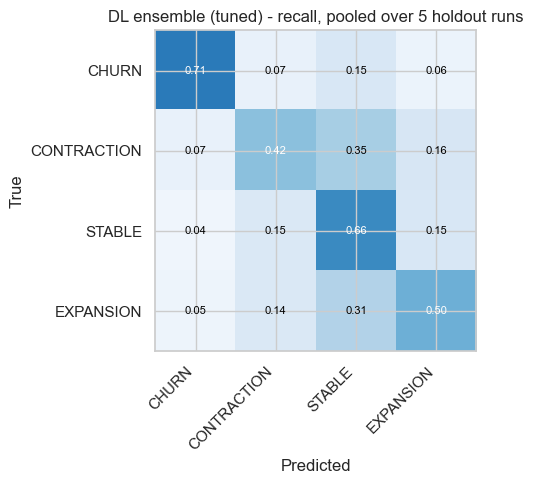

,CHURN,CONTRACTION,STABLE,EXPANSION
CHURN,0.714,0.072,0.152,0.062
CONTRACTION,0.071,0.421,0.347,0.162
STABLE,0.043,0.147,0.655,0.155
EXPANSION,0.048,0.144,0.312,0.496


In [17]:
# Aggregate recall-confusion for the tuned DL ensemble over the 5 repeated-holdout runs.
# INFERENCE ONLY: reloads the 15 saved checkpoints (clf_dl_rh_seed*_m*.pt), reproduces each seed's
# leakage-safe scalers + tuned decision weights, and POOLS the holdout predictions across all 5 runs.
from sklearn.metrics import confusion_matrix

# unstandardised base+horizon numerics (NaNs intact) to re-fit each seed's scaler, exactly as §9b
_dfh = U.load_events('base+horizon', modellable_only=True)
assert np.array_equal(_ev_keys(_dfh), seq_keys), 'reload misaligned with sequence cache'
_Xhnum_raw = U.build_X(_dfh, 'base+horizon')[NUM_COLS2].to_numpy('float32')
del _dfh; gc.collect()

# snapshot the canonical split + scalers, restore at the end
_ho0, _fold0 = df['is_holdout'].copy(), df['user_fold'].copy()
_Xnum2_def, _sm_def, _ss_def = Xnum2, seq_mean, seq_std
_rng = np.random.default_rng(U.RANDOM_STATE)

agg_true, agg_pred = [], []
t0 = time.time()
for si, seed in enumerate(U.RUN_SEEDS):
    U.assign_run_split(df, seed)
    m_dev, m_ho = U.dev_mask(df), U.holdout_mask(df)
    dev_r = np.where(m_dev)[0]
    val_r = np.where(m_dev & (df['user_fold'].to_numpy() == 0))[0]
    ho_r  = np.where(m_ho)[0]
    # per-seed leakage-safe standardisation on dev only -> rebind the globals the Datasets read
    raw = _Xhnum_raw.copy()
    med = np.nanmedian(raw[m_dev], axis=0)
    jj = np.where(np.isnan(raw)); raw[jj] = np.take(med, jj[1])
    mu = raw[m_dev].mean(0); sd = raw[m_dev].std(0) + 1e-6
    Xnum2 = ((raw - mu) / sd).astype('float32'); del raw; gc.collect()
    samp = _rng.choice(dev_r, size=min(120_000, len(dev_r)), replace=False)
    sq = np.log1p(np.clip(np.asarray(seq_arr[np.sort(samp)]).astype('float32'), 0, SEQ_CLIP))
    sq = sq.reshape(-1, len(SEQ_FEATURES)); nzr = sq.any(1)
    seq_mean = sq[nzr].mean(0).astype('float32'); seq_std = (sq[nzr].std(0) + 1e-6).astype('float32')
    del sq; gc.collect()
    # reload the 3 saved members and run inference (no training)
    vp, hp = [], []
    for k in range(N_SEEDS):
        ck = U.DATA / f'clf_dl_rh_seed{seed}_m{k}.pt'
        assert ck.exists(), f'missing checkpoint {ck.name}'
        mdl = HybridNetV2(len(NUM_COLS2), cat_cards).to(device)
        mdl.load_state_dict(torch.load(ck, map_location=device)); mdl.eval()
        vp.append(predict_rows_v2(mdl, val_r)); hp.append(predict_rows_v2(mdl, ho_r))
        del mdl; gc.collect()
    val_ens_s, ho_ens_s = np.mean(vp, 0), np.mean(hp, 0)
    W_s, _, _ = tune_weights(val_ens_s, y[val_r], seed=U.RANDOM_STATE + si)   # reproduces §9b's weights
    agg_true.append(y[ho_r]); agg_pred.append((ho_ens_s * W_s).argmax(1))
    print(f'seed {seed}: pooled {len(ho_r):,} holdout preds  ({(time.time()-t0)/60:.1f} min)')

# restore the canonical split + scalers
df['is_holdout'], df['user_fold'] = _ho0, _fold0
Xnum2, seq_mean, seq_std = _Xnum2_def, _sm_def, _ss_def
del _Xhnum_raw; gc.collect()

y_true_all = np.concatenate(agg_true); y_pred_all = np.concatenate(agg_pred)
print('pooled holdout examples:', f'{len(y_true_all):,}',
      '| aggregate macro-F1:', round(f1_score(y_true_all, y_pred_all, average='macro'), 4))

# persist the aggregate recall matrix and plot recall only
cm_recall = confusion_matrix(y_true_all, y_pred_all,
                             labels=list(range(len(U.MODEL_CLASSES))), normalize='true')
pd.DataFrame(cm_recall, index=U.MODEL_CLASSES, columns=U.MODEL_CLASSES).round(4) \
    .to_csv(U.DATA / 'clf_dl_ensemble_cv_confusion_recall.csv')

fig, ax = plt.subplots(figsize=(5.8, 5.0))
U.plot_confusion(y_true_all, y_pred_all, U.MODEL_CLASSES, ax=ax, normalize='true',
                 title=f'Deep-learning ensemble: recall (pooled over {len(U.RUN_SEEDS)} holdout runs)')
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_dl_ensemble_cv_confusion.png', dpi=150); plt.show()
pd.DataFrame(cm_recall, index=U.MODEL_CLASSES, columns=U.MODEL_CLASSES).round(3)


### Aggregate confusion matrix - mean ± SE across the 5 holdout runs

Instead of pooling all runs into one matrix, compute the recall (row-normalised)
confusion **per run** and report the **mean ± standard error** of each cell across
the 5 repeated-holdout runs — so the diagonal is per-class recall with an error
bar, consistent with the mean ± SE headline metric. Reuses the per-run predictions
already in memory (`agg_true` / `agg_pred`); no models are re-run.


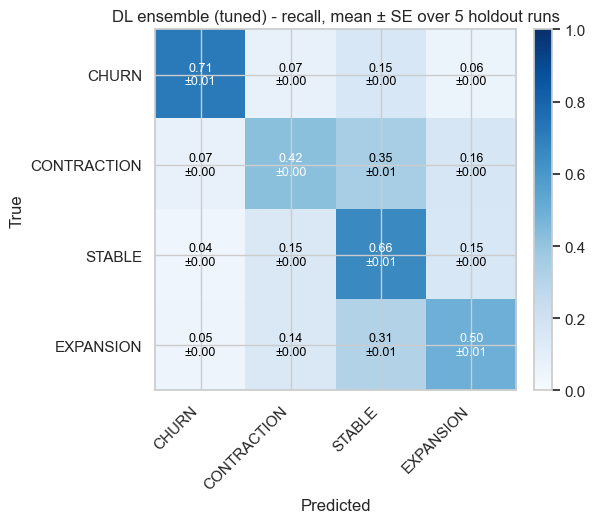

per-class recall (mean ± SE over 5 runs):
  CHURN        0.714 ± 0.008
  CONTRACTION  0.421 ± 0.005
  STABLE       0.655 ± 0.006
  EXPANSION    0.496 ± 0.008

recall confusion (mean ± SE):
                     CHURN    CONTRACTION         STABLE      EXPANSION
CHURN        0.714 ± 0.008  0.072 ± 0.004  0.152 ± 0.005  0.062 ± 0.003
CONTRACTION  0.071 ± 0.002  0.421 ± 0.005  0.347 ± 0.007  0.162 ± 0.005
STABLE       0.043 ± 0.002  0.147 ± 0.003  0.655 ± 0.006  0.155 ± 0.005
EXPANSION    0.048 ± 0.002  0.144 ± 0.004  0.312 ± 0.008  0.496 ± 0.008


,CHURN,CONTRACTION,STABLE,EXPANSION
CHURN,0.714 ± 0.008,0.072 ± 0.004,0.152 ± 0.005,0.062 ± 0.003
CONTRACTION,0.071 ± 0.002,0.421 ± 0.005,0.347 ± 0.007,0.162 ± 0.005
STABLE,0.043 ± 0.002,0.147 ± 0.003,0.655 ± 0.006,0.155 ± 0.005
EXPANSION,0.048 ± 0.002,0.144 ± 0.004,0.312 ± 0.008,0.496 ± 0.008


In [18]:
# Per-run recall confusion -> MEAN +/- SE across the 5 repeated-holdout runs.
# No re-inference: reuses agg_true / agg_pred (the per-seed holdout predictions from the cell above).
from sklearn.metrics import confusion_matrix
_K = len(U.MODEL_CLASSES)
_cms = np.stack([confusion_matrix(t, p, labels=list(range(_K)), normalize='true')
                 for t, p in zip(agg_true, agg_pred)])          # (n_runs, K, K); row-normalised = recall
cm_mean = _cms.mean(0)
cm_se   = _cms.std(0, ddof=1) / np.sqrt(_cms.shape[0])
pd.DataFrame(cm_mean, index=U.MODEL_CLASSES, columns=U.MODEL_CLASSES).round(4) \
    .to_csv(U.DATA / 'clf_dl_ensemble_cv_confusion_recall_mean.csv')
pd.DataFrame(cm_se, index=U.MODEL_CLASSES, columns=U.MODEL_CLASSES).round(4) \
    .to_csv(U.DATA / 'clf_dl_ensemble_cv_confusion_recall_se.csv')

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(cm_mean, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(_K), U.MODEL_CLASSES, rotation=45, ha='right')
ax.set_yticks(range(_K), U.MODEL_CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Deep-learning ensemble: recall (mean \u00b1 SE over {_cms.shape[0]} holdout runs)')
_thr = cm_mean.max() / 2
for i in range(_K):
    for j in range(_K):
        ax.text(j, i, f'{cm_mean[i, j]:.2f}\n\u00b1{cm_se[i, j]:.2f}', ha='center', va='center',
                color='white' if cm_mean[i, j] > _thr else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_dl_ensemble_cv_confusion_meanSE.png', dpi=150); plt.show()

# per-class recall (diagonal) with error, and a full "mean +/- SE" cell table
print('per-class recall (mean \u00b1 SE over', _cms.shape[0], 'runs):')
for i, cls in enumerate(U.MODEL_CLASSES):
    print(f'  {cls:12s} {cm_mean[i, i]:.3f} \u00b1 {cm_se[i, i]:.3f}')
_disp = pd.DataFrame([[f'{cm_mean[i, j]:.3f} \u00b1 {cm_se[i, j]:.3f}' for j in range(_K)] for i in range(_K)],
                     index=U.MODEL_CLASSES, columns=U.MODEL_CLASSES)
print('\nrecall confusion (mean \u00b1 SE):'); print(_disp)
_disp
